In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

### Seismic Story Drift 

All seismic story drifts were obtained directly from MIDAS and expressed in terms of 1/x, where x is the reciprocal of the story drift ratio. The tolerable drift was calculated and reduced by the amplification for inelastic drift which is 0.7R.

## Story Shear
(Response Spectrum Case)

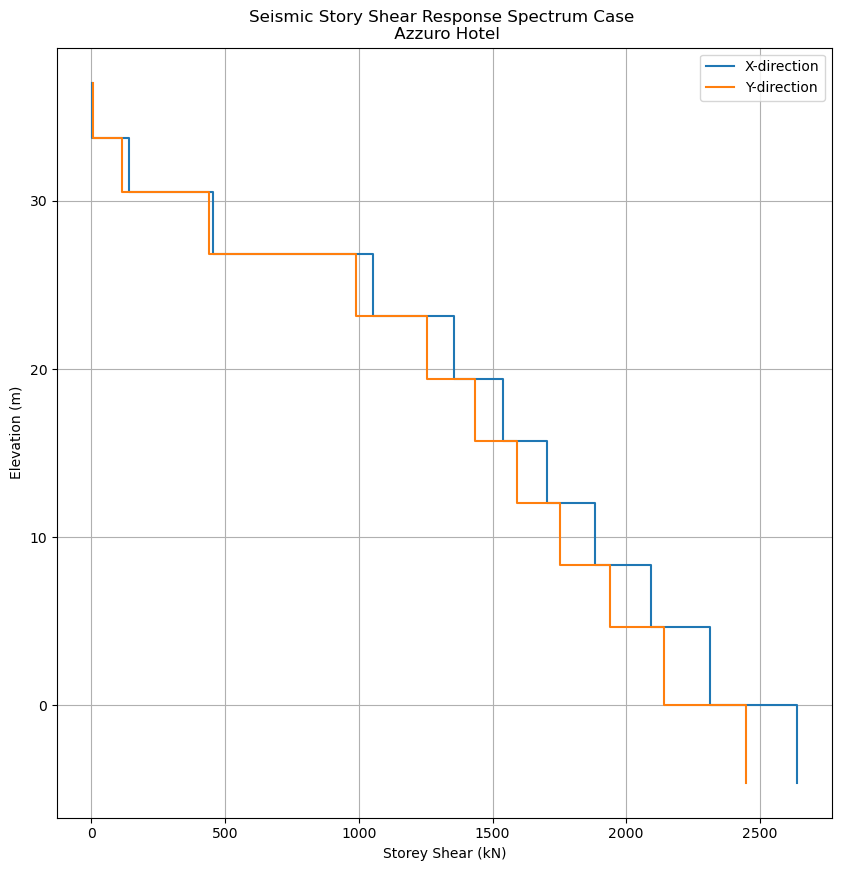

In [2]:
ssrsf = pd.read_excel('rsshear.xls')

length = len(ssrsf)

height = []
shear_major = []
shear_ortho = []


i = 0
while i < length:
    case_index = ssrsf['case'][i]
    if(case_index == 'RS-Major(RS)'):
        height.append(ssrsf['height'][i])    
    i = i + 1
i = 0
while i < length:
    case_index = ssrsf['case'][i]
    if(case_index == 'RS-Major(RS)'):
        shear_x = ssrsf['X'][i]
        shear_y = ssrsf['Y'][i]
        resultant = math.sqrt(math.pow(shear_x,2) + math.pow(shear_y,2))
        shear_major.append(resultant)
    if(case_index == 'RS-Ortho(RS)'):
        shear_x = ssrsf['X'][i]
        shear_y = ssrsf['Y'][i]
        resultant = math.sqrt(math.pow(shear_x,2) + math.pow(shear_y,2))
        shear_ortho.append(resultant)     
    i = i + 1
    

plt.figure(figsize=(10, 10))
plt.step(shear_major, height, label = "X-direction")
plt.step(shear_ortho, height, label = "Y-direction")
plt.legend()
plt.grid()
plt.title("Seismic Story Shear Response Spectrum Case \n Azzuro Hotel")
plt.xlabel("Storey Shear (kN)")
plt.ylabel("Elevation (m)")
plt.show()


## Overturning Moment

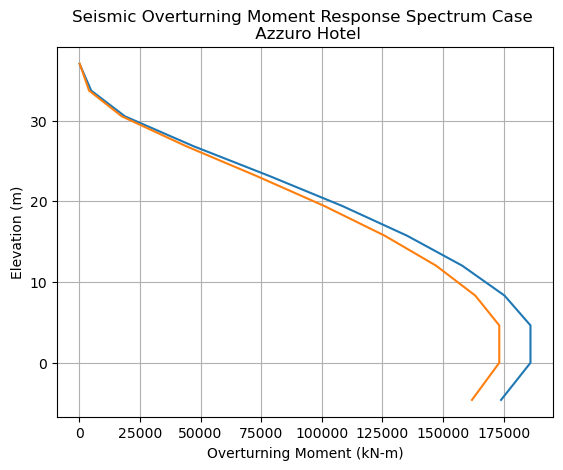

In [10]:
length = len(shear_major)
OT_major = []
OT_ortho = []
ot_at_x = 0
ot_at_y = 0
i = 0
while i < length:
#     if height[i] <= 0:
#         continue
#     else:
    major = shear_major[i]*height[i]
    ortho = shear_ortho[i]*height[i]
    ot_at_x = ot_at_x + major
    ot_at_y = ot_at_y + ortho
    OT_major.append(ot_at_x)
    OT_ortho.append(ot_at_y)
    i = i + 1
    
# print(OT_major)

plt.plot(OT_major, height, label = "Bending about X")
plt.plot(OT_ortho, height, label = "Bending about Y")
plt.grid()
plt.title("Seismic Overturning Moment Response Spectrum Case \n Azzuro Hotel")
plt.xlabel("Overturning Moment (kN-m)")
plt.ylabel("Elevation (m)")

plt.show()